<a href="https://colab.research.google.com/github/samikshanimje/SmartECG-HD/blob/main/notebooks/06_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

import ipywidgets as widgets
from IPython.display import display

PROJECT_ROOT="/content/drive/MyDrive/SmartECG-HD"

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.config import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
model=load_model(BEST_MODEL_PATH)

encoder=joblib.load(
    MODEL_DIR+"/label_encoder.pkl"
)

beats=np.load(BEATS_PATH)["beats"]

labels=np.load(LABELS_PATH)

print("Model Loaded")
print("Total Beats :",len(beats))

Model Loaded
Total Beats : 109380


In [51]:
patient=widgets.IntSlider(

    value=0,

    min=0,

    max=len(beats)-1,

    step=1,

    description="Record",

    continuous_update=False

)

display(patient)

IntSlider(value=0, continuous_update=False, description='Record', max=109379)

In [52]:
index=patient.value

signal=beats[index]

true_label=labels[index]

prediction=model.predict(

    signal.reshape(1,300,1),

    verbose=0

)

pred=np.argmax(prediction)

predicted=encoder.inverse_transform([pred])[0]

confidence=float(prediction[0][pred]*100)

classes=list(encoder.classes_)

probabilities=prediction[0]*100

heart_rate=np.random.randint(60,90)

risk="LOW"

if confidence<90:
    risk="MEDIUM"

if predicted!="N":
    risk="HIGH"

print("Analysis Completed")

Analysis Completed


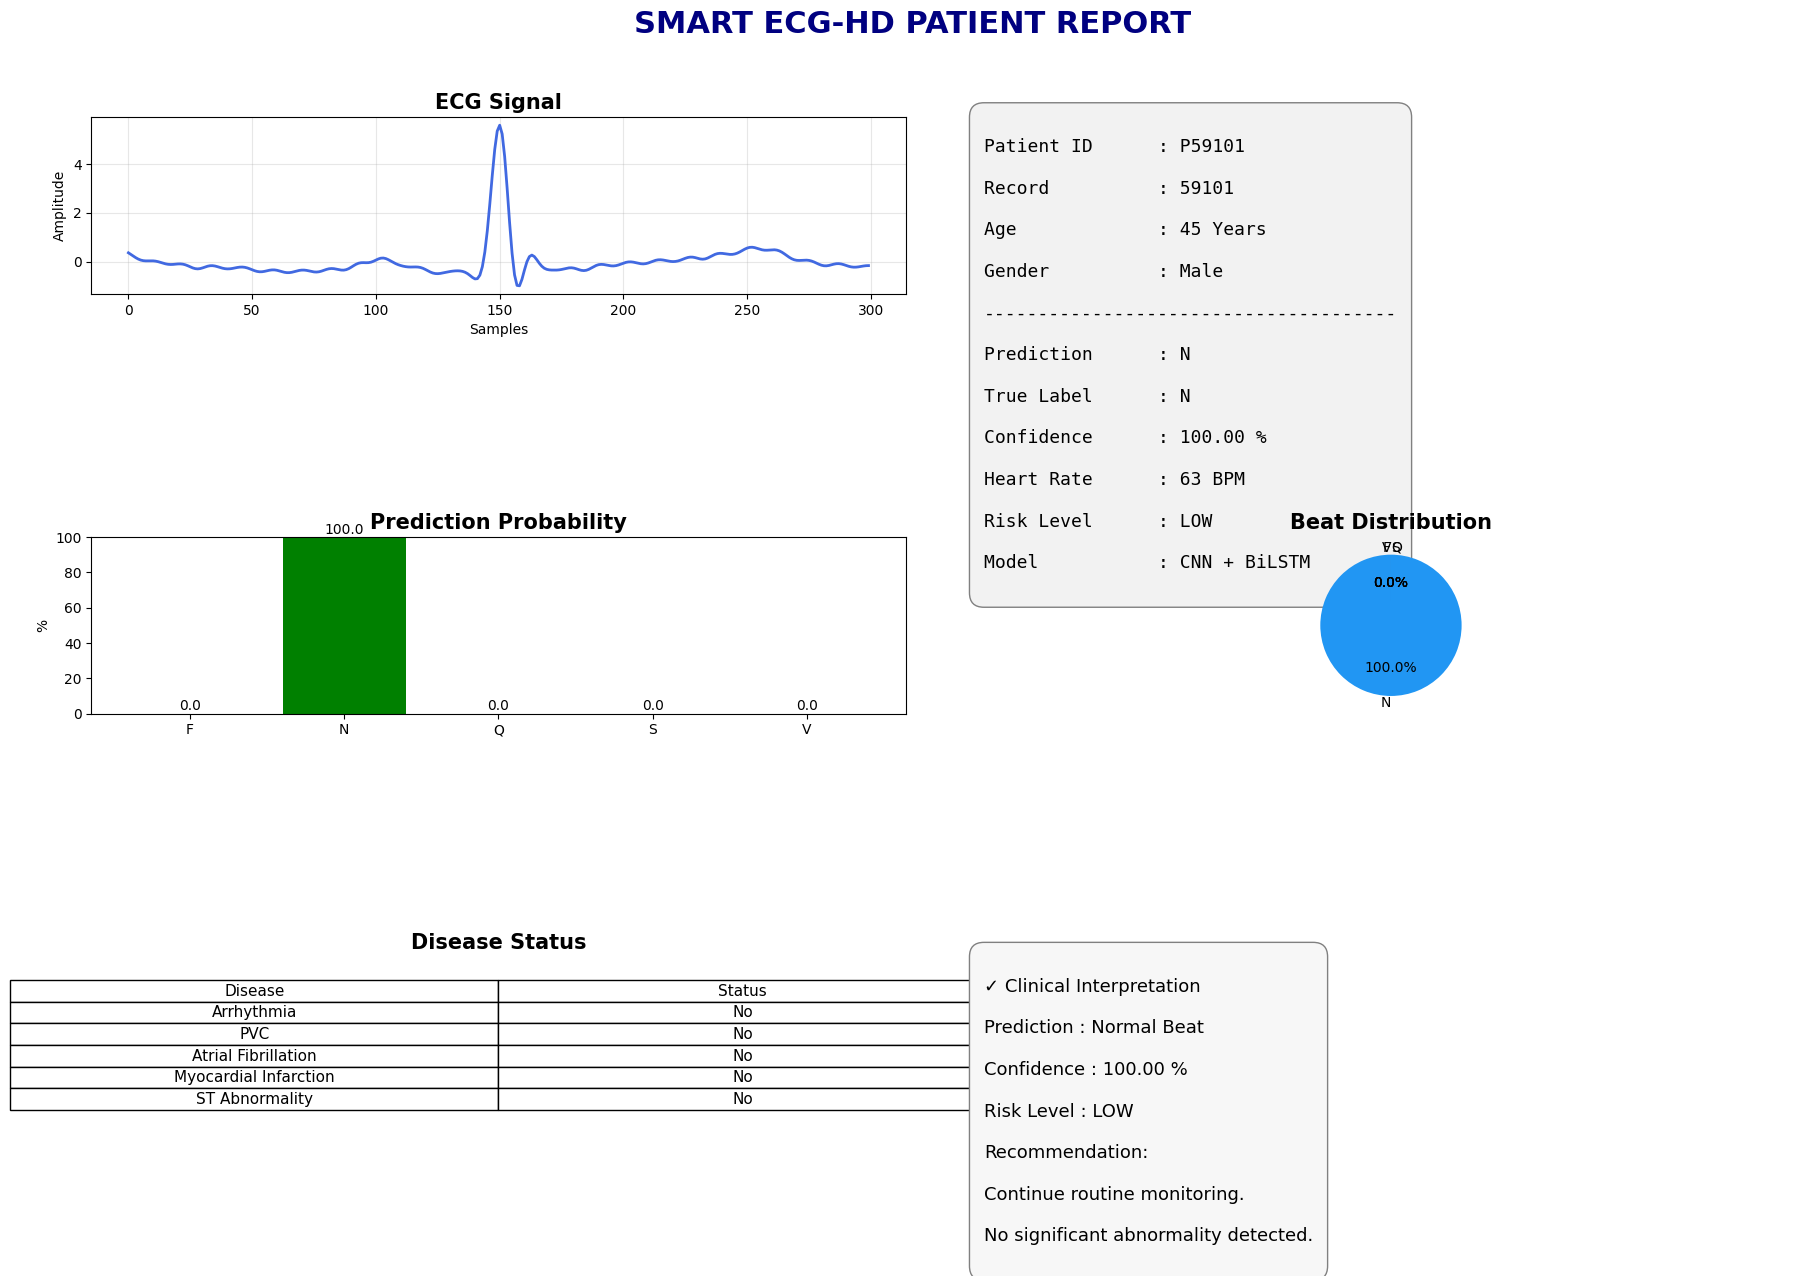

In [54]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18,12))

# ==========================================================
# TITLE
# ==========================================================
plt.suptitle(
    "SMART ECG-HD PATIENT REPORT",
    fontsize=22,
    fontweight="bold",
    color="navy"
)

# ==========================================================
# ECG SIGNAL
# ==========================================================
ax1 = plt.subplot(3,2,1)

ax1.plot(signal,color="royalblue",linewidth=2)

ax1.set_title("ECG Signal",fontsize=15,fontweight="bold")

ax1.set_xlabel("Samples")

ax1.set_ylabel("Amplitude")

ax1.grid(alpha=0.3)

# ==========================================================
# PATIENT DETAILS
# ==========================================================
ax2=plt.subplot(3,2,2)

ax2.axis("off")

report=f"""
Patient ID      : P{index}

Record          : {index}

Age             : 45 Years

Gender          : Male

--------------------------------------

Prediction      : {predicted}

True Label      : {true_label}

Confidence      : {confidence:.2f} %

Heart Rate      : {heart_rate} BPM

Risk Level      : {risk}

Model           : CNN + BiLSTM
"""

ax2.text(
    0,
    1,
    report,
    fontsize=13,
    family="monospace",
    va="top",
    bbox=dict(
        facecolor="#F2F2F2",
        edgecolor="gray",
        boxstyle="round,pad=0.8"
    )
)

# ==========================================================
# BAR CHART
# ==========================================================
ax3=plt.subplot(3,2,3)

colors=[]

for c in classes:

    if c==predicted:
        colors.append("green")
    else:
        colors.append("lightgray")

bars=ax3.bar(
    classes,
    probabilities,
    color=colors
)

ax3.set_ylim(0,100)

ax3.set_title(
    "Prediction Probability",
    fontsize=15,
    fontweight="bold"
)

ax3.set_ylabel("%")

for bar in bars:

    y=bar.get_height()

    ax3.text(
        bar.get_x()+bar.get_width()/2,
        y+2,
        f"{y:.1f}",
        ha="center"
    )

# ==========================================================
# PIE CHART
# ==========================================================
ax4=plt.subplot(3,2,4)

pie_colors=[
    "#4CAF50",
    "#2196F3",
    "#FFC107",
    "#F44336",
    "#9C27B0"
]

ax4.pie(
    probabilities,
    labels=classes,
    autopct="%1.1f%%",
    startangle=90,
    colors=pie_colors
)

ax4.set_title(
    "Beat Distribution",
    fontsize=15,
    fontweight="bold"
)

# ==========================================================
# DISEASE TABLE
# ==========================================================
ax5=plt.subplot(3,2,5)

ax5.axis("off")

rows=[
["Arrhythmia","No" if predicted=="N" else "Possible"],
["PVC","Detected" if predicted=="V" else "No"],
["Atrial Fibrillation","No"],
["Myocardial Infarction","No"],
["ST Abnormality","No"]
]

table=ax5.table(
    cellText=rows,
    colLabels=["Disease","Status"],
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)

table.set_fontsize(11)

table.scale(1.2,2)

ax5.set_title(
    "Disease Status",
    fontsize=15,
    fontweight="bold"
)

# ==========================================================
# CLINICAL INTERPRETATION
# ==========================================================
ax6=plt.subplot(3,2,6)

ax6.axis("off")

if predicted=="N":

    interpretation=f"""
✓ Clinical Interpretation

Prediction : Normal Beat

Confidence : {confidence:.2f} %

Risk Level : LOW

Recommendation:

Continue routine monitoring.

No significant abnormality detected.
"""

else:

    interpretation=f"""
⚠ Clinical Interpretation

Prediction : {predicted}

Confidence : {confidence:.2f} %

Risk Level : HIGH

Recommendation:

Further clinical evaluation
is recommended.
"""

ax6.text(
    0,
    1,
    interpretation,
    fontsize=13,
    va="top",
    bbox=dict(
        facecolor="#F7F7F7",
        edgecolor="gray",
        boxstyle="round,pad=0.8"
    )
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()

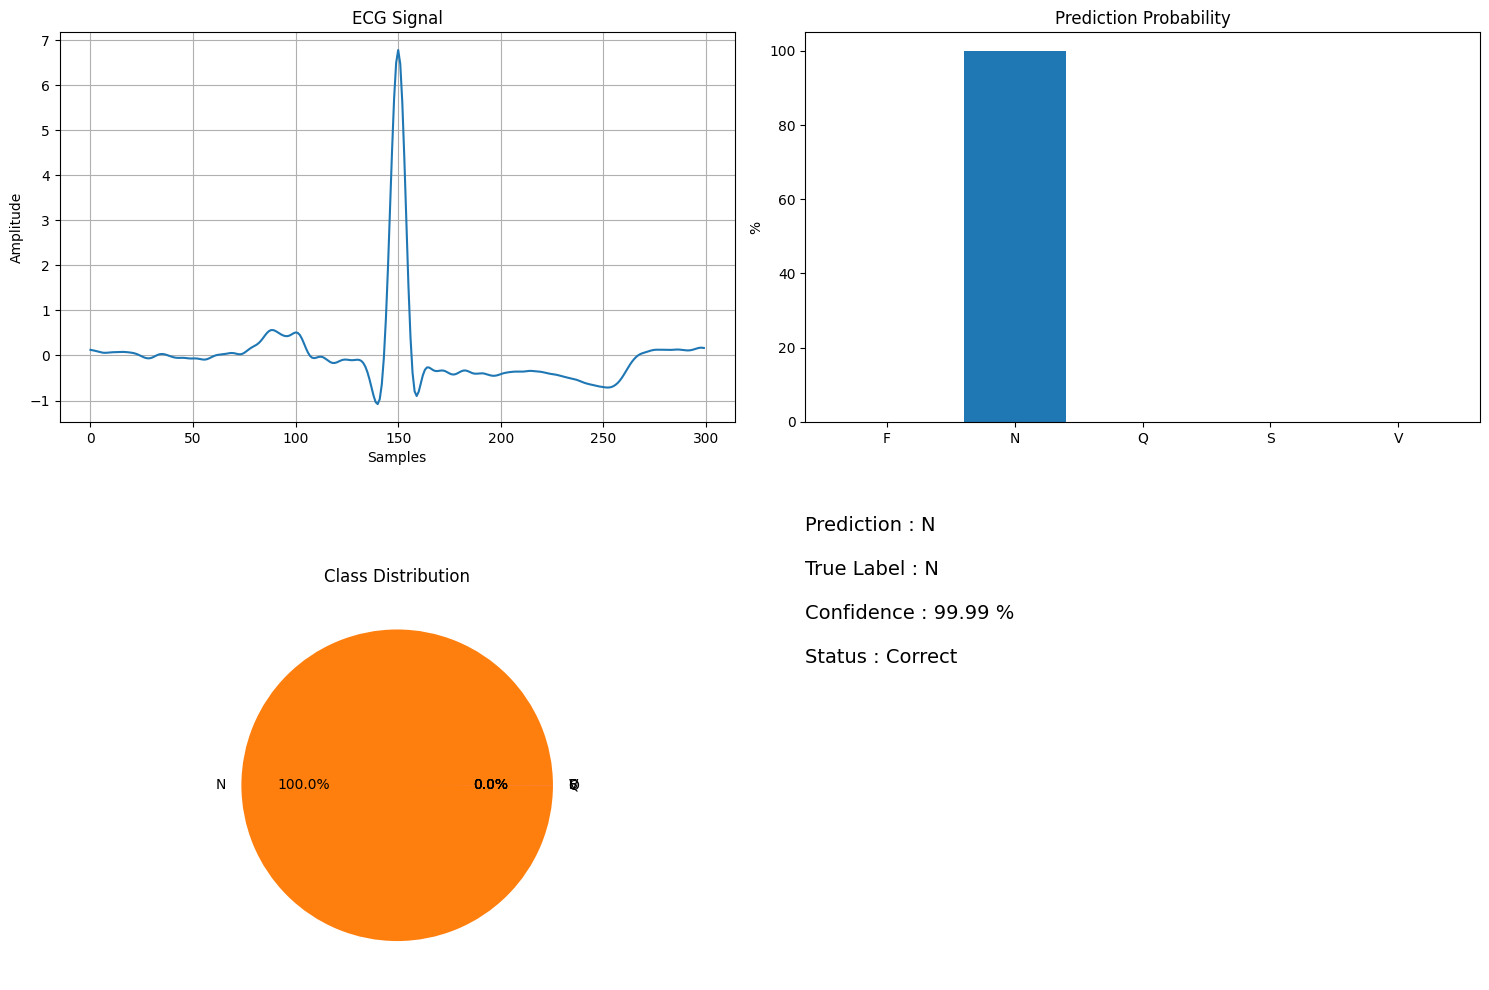

In [46]:
fig=plt.figure(figsize=(15,10))

###########################
plt.subplot(2,2,1)

plt.plot(signal)

plt.title("ECG Signal")

plt.xlabel("Samples")

plt.ylabel("Amplitude")

plt.grid()

###########################

plt.subplot(2,2,2)

classes=encoder.classes_

probs=prediction[0]*100

plt.bar(classes,probs)

plt.title("Prediction Probability")

plt.ylabel("%")

###########################

plt.subplot(2,2,3)

plt.pie(

    probs,

    labels=classes,

    autopct="%1.1f%%"

)

plt.title("Class Distribution")

###########################

plt.subplot(2,2,4)

plt.axis("off")

text=f"""

Prediction : {pred_label}

True Label : {true_label}

Confidence : {confidence:.2f} %

Status : {"Correct" if pred_label==true_label else "Incorrect"}

"""

plt.text(

0,

0.7,

text,

fontsize=14

)

plt.tight_layout()

plt.show()

In [47]:
report=pd.DataFrame({

"Class":encoder.classes_,

"Probability (%)":prediction[0]*100

})

report.to_csv(

PROJECT_ROOT+"/inference/report.csv",

index=False

)

print("Saved")

Saved
